# Image Acquisition

Acquire a full-frame image, a cropped rectangle scan, and images from multiple detectors.


### Run the servers

Make sure you are on the VPN and the AutoScript server is running. Then start the asyncroscopy Tango servers from the repository root:

```bash
uv run scripts/run_servers.py
```


### Imports


In [1]:
import os
import json
import tango
import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt
from tiled.client import from_uri

%matplotlib ipympl

### Ping servers


In [2]:
DB_HOST = "10.46.217.241"
DB_PORT = 9094

DB_HOST = '127.0.0.1'
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope']

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/microscope/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/microscope/default ON
asyncroscopy/data/default ON


### Start Tiled data server


In [5]:
config = json.loads(data.get_config())
config

{'host': '127.0.0.1',
 'port': 9091,
 'uri': 'http://127.0.0.1:9091',
 'save_path': 'outputs/tiled_acquisitions',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; serving path; files register manually',
 'tiled_server_serving': 'outputs/tiled_acquisitions'}

In [14]:
# Set the save path (or change it)
data.save_path = "D:/microscopedata/tiled/ahoust17/2026_05_29_test/"

In [15]:
config = json.loads(data.get_config())
config

{'host': '127.0.0.1',
 'port': 9091,
 'uri': 'http://127.0.0.1:9091',
 'save_path': '/Users/austin/Desktop/new_tiled',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; serving path; files register manually',
 'tiled_server_serving': '/Users/austin/Desktop/new_tiled'}

In [16]:
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: []


### Configure scan


In [17]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]

print("dwell_time :", scan.dwell_time)
print("image size :", scan.imsize)
print("scan region:", list(scan.scan_region))


dwell_time : 1e-08
image size : 512
scan region: [np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]


### Acquire a HAADF image


In [18]:
# Acquire a HAADF image
data_key = microscope.acquire_scanned_image(["haadf"])


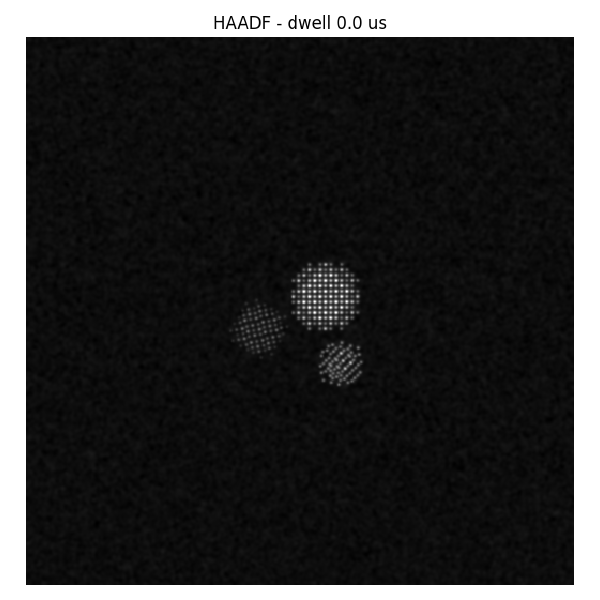

In [19]:
# Read that image
image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

In [6]:
# print("Metadata:")
# pprint(metadata)

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)


Image shape: (512, 512)
Image dtype: uint16


### Acquire multiple detectors


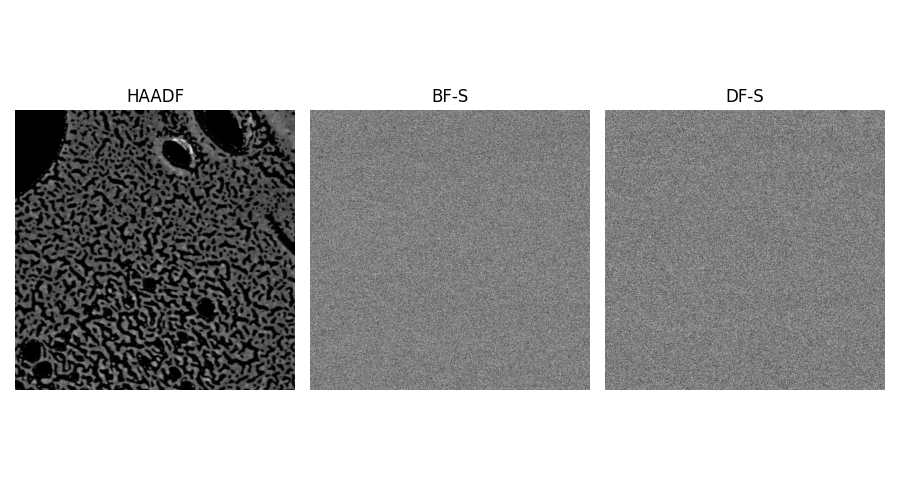

In [7]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]

key = microscope.acquire_scanned_image(["HAADF", "BF-S", "DF-S"])
dset = client[key]["image"]

images = []
names = []
for detector_name in dset:
    image = dset[detector_name].read()
    images.append(image)
    names.append(detector_name)

fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 5))
for ax, im, n in zip(axes, images, names):
    ax.imshow(im, cmap="gray")
    ax.set_title(str(n).upper())
    ax.axis("off")
fig.tight_layout()


### Acquire a cropped rectangle scan


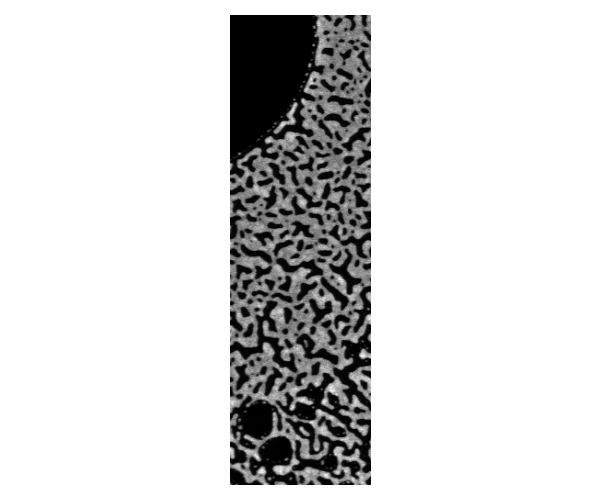

In [8]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, .3, 1]

key = microscope.acquire_scanned_image(["HAADF"])
dset = client[key]["image"]
image = dset["HAADF"].read()

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(image, cmap="gray")
ax.axis("off")
plt.tight_layout()
